# 🍔 Food Delivery Time — Analysis & Prediction

**Objective:** Understand what factors affect food delivery time and build a regression model to predict it.

| Detail | Info |
|--------|------|
| Dataset | Food_Delivery_Times.csv |
| Rows | 1000 orders |
| Target | `Delivery_Time_min` |
| Features | Distance, Weather, Traffic, Vehicle, Prep Time, Experience |
| Task | Regression (predict delivery time in minutes) |

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

## 2. Load & Understand the Data

In [2]:
df = pd.read_csv('Food_Delivery_Times.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (1000, 9)


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [4]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,970.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.579381,56.732000
std,288.819436,5.696656,7.204553,2.914394,22.070915
min,1.000000,0.590000,5.000000,0.000000,8.000000
25%,250.750000,5.105000,11.000000,2.000000,41.000000
50%,500.500000,10.190000,17.000000,5.000000,55.500000
75%,750.250000,15.017500,23.000000,7.000000,71.000000
max,1000.000000,19.990000,29.000000,9.000000,153.000000


## 3. Data Cleaning

In [5]:
# Check missing values
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Order_ID                   0
Distance_km                0
Weather                   30
Traffic_Level             30
Time_of_Day               30
Vehicle_Type               0
Preparation_Time_min       0
Courier_Experience_yrs    30
Delivery_Time_min          0
dtype: int64


In [6]:
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [7]:
# Fill missing categorical values with mode
for col in ['Weather', 'Traffic_Level', 'Time_of_Day']:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill missing numerical value with median
df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].median(), inplace=True)

print('Missing values after cleaning:')
print(df.isnull().sum())

Missing values after cleaning:
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64


In [8]:
# Drop Order_ID — not useful for analysis
df.drop('Order_ID', axis=1, inplace=True)
print(f'Final shape: {df.shape}')

Final shape: (1000, 8)


In [9]:
# Preview cleaned data before saving
print('Cleaned Data — First 5 Rows:')
print(df.head())
print(f'\nShape : {df.shape}')
print(f'Nulls : {df.isnull().sum().sum()}')

Cleaned Data — First 5 Rows:
   Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0         7.93   Windy           Low   Afternoon      Scooter   
1        16.42   Clear        Medium     Evening         Bike   
2         9.52   Foggy           Low       Night      Scooter   
3         7.44   Rainy        Medium   Afternoon      Scooter   
4        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  

Shape : (1000, 8)
Nulls : 0


In [10]:
# Save cleaned data to CSV
df.to_csv('Food_Delivery_Cleaned.csv', index=False)
print('✅ Cleaned file saved as Food_Delivery_Cleaned.csv')

✅ Cleaned file saved as Food_Delivery_Cleaned.csv


## 4. Exploratory Data Analysis (EDA)

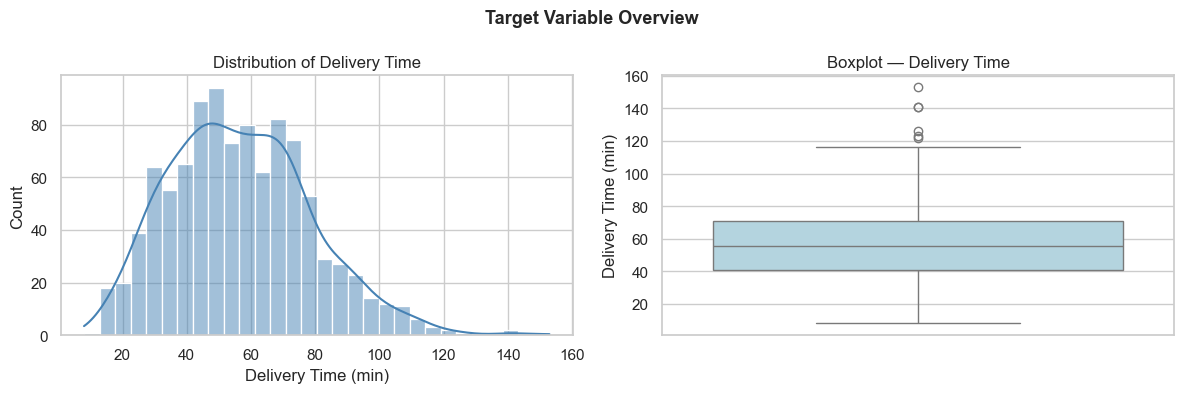

Average : 56.7 min
Median  : 55.5 min
Max     : 153 min


In [11]:
# --- Target Variable: How is Delivery Time distributed? ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Delivery_Time_min'], bins=30, kde=True, color='steelblue', ax=axes[0])
axes[0].set_title('Distribution of Delivery Time')
axes[0].set_xlabel('Delivery Time (min)')
axes[0].set_ylabel('Count')

sns.boxplot(y=df['Delivery_Time_min'], color='lightblue', ax=axes[1])
axes[1].set_title('Boxplot — Delivery Time')
axes[1].set_ylabel('Delivery Time (min)')

plt.suptitle('Target Variable Overview', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Average : {df['Delivery_Time_min'].mean():.1f} min")
print(f"Median  : {df['Delivery_Time_min'].median():.1f} min")
print(f"Max     : {df['Delivery_Time_min'].max()} min")

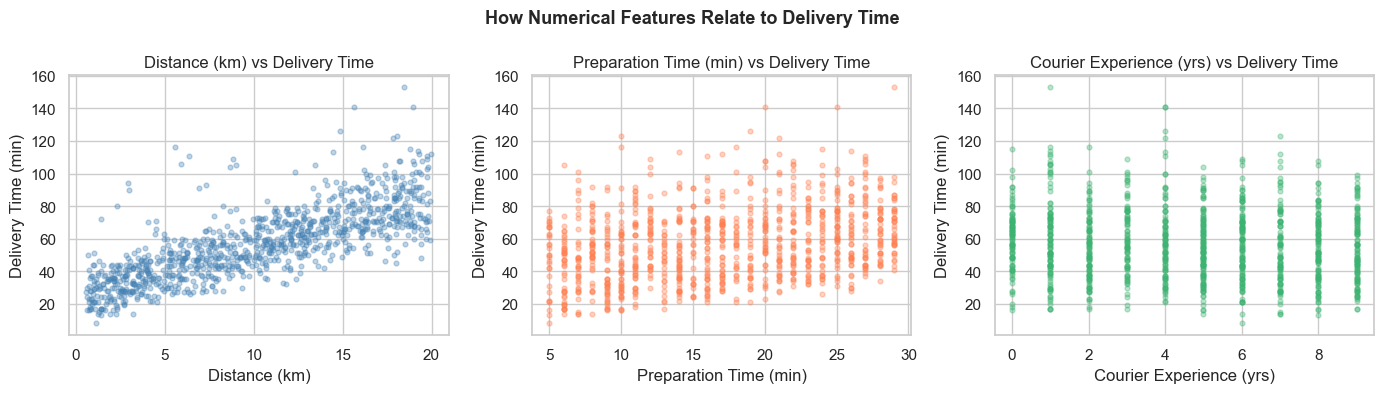

In [12]:
# --- Numerical Features vs Delivery Time ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

scatter_cols = [
    ('Distance_km',            'Distance (km)',            'steelblue'),
    ('Preparation_Time_min',   'Preparation Time (min)',   'coral'),
    ('Courier_Experience_yrs', 'Courier Experience (yrs)', 'mediumseagreen'),
]

for ax, (col, label, color) in zip(axes, scatter_cols):
    ax.scatter(df[col], df['Delivery_Time_min'], alpha=0.35, color=color, s=12)
    ax.set_xlabel(label)
    ax.set_ylabel('Delivery Time (min)')
    ax.set_title(f'{label} vs Delivery Time')

plt.suptitle('How Numerical Features Relate to Delivery Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

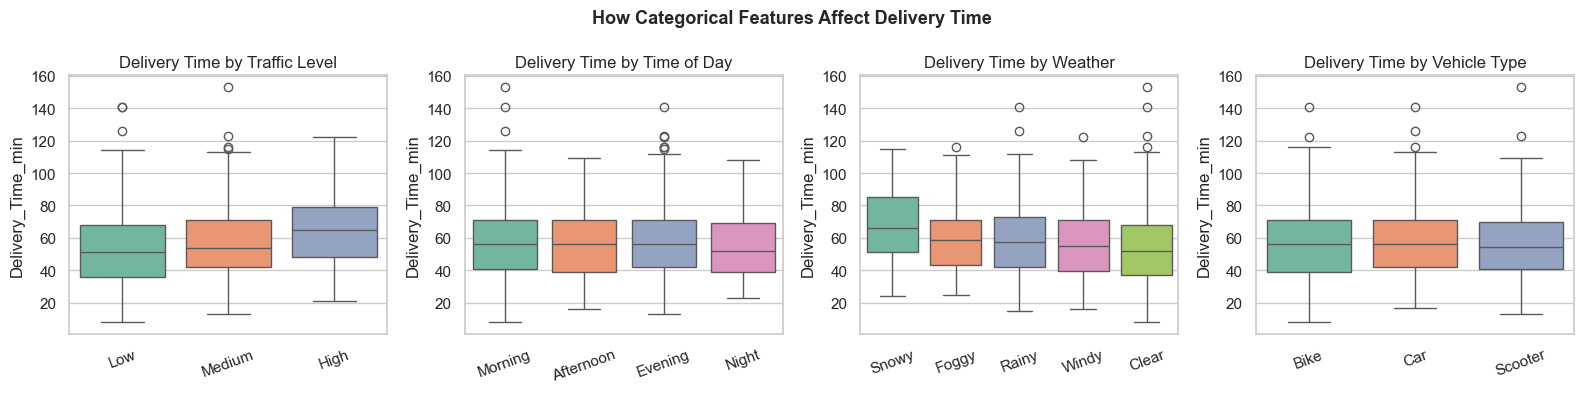

In [13]:
# --- Categorical Features vs Delivery Time ---
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

cat_info = [
    ('Traffic_Level', ['Low', 'Medium', 'High']),
    ('Time_of_Day',   ['Morning', 'Afternoon', 'Evening', 'Night']),
    ('Weather',       None),
    ('Vehicle_Type',  None),
]

for ax, (col, order) in zip(axes, cat_info):
    if order is None:
        order = df.groupby(col)['Delivery_Time_min'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Delivery_Time_min', order=order, palette='Set2', ax=ax)
    ax.set_title(f'Delivery Time by {col.replace("_", " ")}')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('How Categorical Features Affect Delivery Time', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

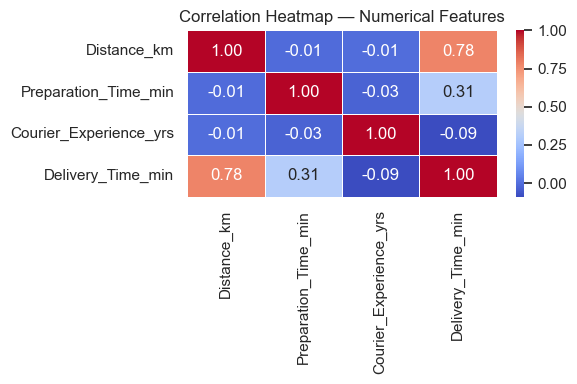

In [14]:
# Correlation heatmap — shows which numerical features are most related to delivery time
plt.figure(figsize=(6, 4))
num_cols = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs', 'Delivery_Time_min']
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

## 5. Encoding Categorical Variables

In [15]:
le = LabelEncoder()

for col in ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']:
    df[col] = le.fit_transform(df[col])

print('Encoding complete.')
df.head()

Encoding complete.


,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


## 6. Model Building

In [16]:
X = df.drop('Delivery_Time_min', axis=1)
y = df['Delivery_Time_min']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Train size: 800 | Test size: 200


In [17]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print('Linear Regression')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_lr):.2f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_lr)):.2f}')
print(f'  R²   : {r2_score(y_test, y_pred_lr):.4f}')

Linear Regression
  MAE  : 7.29
  RMSE : 10.45
  R²   : 0.7563


In [18]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest')
print(f'  MAE  : {mean_absolute_error(y_test, y_pred_rf):.2f}')
print(f'  RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.2f}')
print(f'  R²   : {r2_score(y_test, y_pred_rf):.4f}')

Random Forest
  MAE  : 7.06
  RMSE : 10.01
  R²   : 0.7766


## 7. Model Comparison

In [19]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE':  [mean_absolute_error(y_test, y_pred_lr),
             mean_absolute_error(y_test, y_pred_rf)],
    'RMSE': [np.sqrt(mean_squared_error(y_test, y_pred_lr)),
             np.sqrt(mean_squared_error(y_test, y_pred_rf))],
    'R²':   [r2_score(y_test, y_pred_lr),
             r2_score(y_test, y_pred_rf)]
}).round(3)

comparison.sort_values('R²', ascending=False)

,Model,MAE,RMSE,R²
1,Random Forest,7.065,10.006,0.777
0,Linear Regression,7.287,10.451,0.756


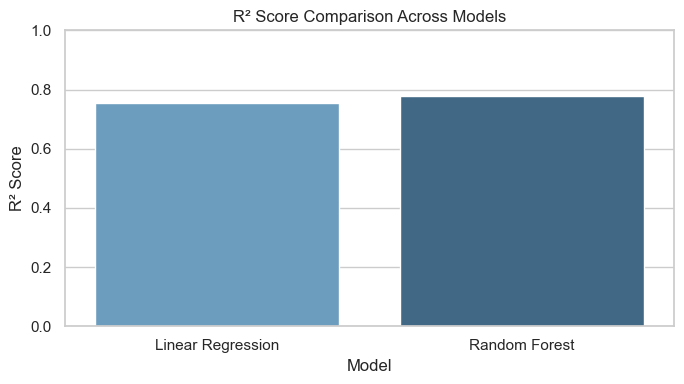

In [20]:
# R² comparison bar chart
plt.figure(figsize=(7, 4))
sns.barplot(data=comparison, x='Model', y='R²', palette='Blues_d')
plt.title('R² Score Comparison Across Models')
plt.ylabel('R² Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

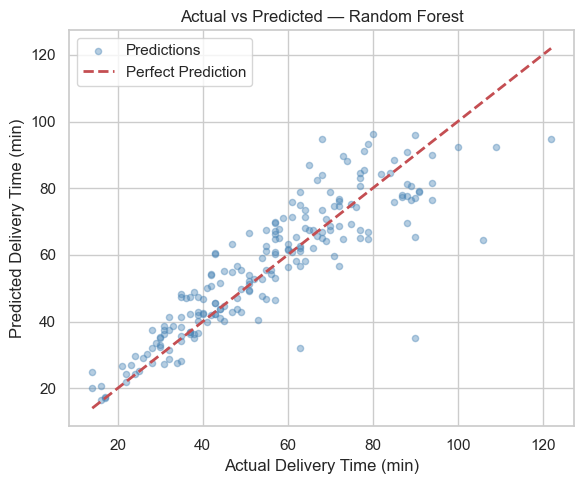

In [21]:
# Actual vs Predicted — Best Model (Random Forest)
# A good model's points should fall close to the red diagonal line
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue', s=20, label='Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Delivery Time (min)')
plt.ylabel('Predicted Delivery Time (min)')
plt.title('Actual vs Predicted — Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

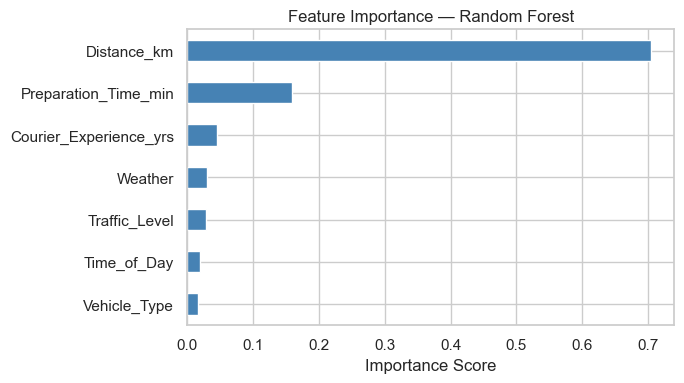

In [22]:
importance = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(7, 4))
importance.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## 9. Conclusion

- **Random Forest** outperformed Linear Regression with a higher R² and lower error scores.
- **Distance** and **Preparation Time** are the strongest predictors of delivery time.
- **High traffic** and **bad weather (Foggy/Stormy)** are associated with longer delivery times.
- More experienced couriers tend to deliver slightly faster.
- Future work could include testing more models or tuning Random Forest for better accuracy.